# L5b Lab: Maximum-Flow Sensitivity and Bottlenecks

Suppose three workers are available to complete four tasks. Each worker can initially accept one assignment, and each task needs only one worker. If one worker can accept a second assignment, can we complete more work? What happens if that worker becomes unavailable instead?

The [L5a lecture](../L5a/CHEME-5800-L5a-Lecture-MaximumFlowProblems-Fall-2026.ipynb) and [worked example](../L5a/CHEME-5800-L5a-WorkedExample-MaximumFlow-Fall-2026.ipynb) represented assignments as flow through a network. One unit of flow from the source to the sink corresponds to one completed assignment. Here, we study __capacity sensitivity__: how changing edge capacities changes the maximum number of assignments the network can complete.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * **Certify a maximum flow:** Check a solver's flow against capacity, conservation, and source–sink balance, then confirm it is maximum by finding a cut whose capacity equals the flow value. Explain why a feasible flow that reaches a cut capacity cannot be improved.
> * **Predict how a capacity change propagates:** Anticipate whether adding capacity to one edge raises the maximum flow or whether other capacities prevent an increase. Anticipate how removing a node's outgoing capacity idles the capacity that feeds it, and check each prediction against the recomputed flow.
> * **Locate the binding bottleneck:** Identify the cut that limits the flow and explain, in terms of the routes that remain, why the limiting cut moves when the network changes. Distinguish a local capacity limit from a network-wide one.

In this lab, we implement the flow checks, compute the baseline with the supplied solver, and then test two changes to the worker at node `3`: a second assignment slot, and an outage in a fresh copy of the baseline network. We predict each outcome first, then check the computed flow and explain what limits the number of assignments.

Let's get started!


___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the course library, the lab's graph-building, flow-validation, and plotting helpers, and the packages used here.

Let's set up our code environment:


In [1]:
# Load packages and paths from this notebook's local setup file -
include(joinpath(@__DIR__, "Include.jl"))

# Choose one theme; after changing it, rerun this cell and the plotting cells.
# A single figure can override this choice with the keyword theme = :dark -
theme(:default)   # light background
# theme(:dark)   # dark background


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5800 course library documentation](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/) for the functions and types used here.

The network is supplied in the local [Workers-Tasks-Bipartite.edgelist file](data/Workers-Tasks-Bipartite.edgelist). Each record lists an edge's source node, target node, cost, lower capacity, and upper capacity. We use the capacity bounds to limit the flow; the cost field is not part of this maximum-flow objective.

__Your implementation:__ Complete the three `TODO` blocks in [src/Compute.jl](src/Compute.jl) for [the `validate_sensitivity_flow(...)` function](docs/validate_sensitivity_flow.md). Check edge capacities, accumulate each node's net inflow, and return the feasibility report described in its docstring. The graph builder, maximum-flow solver, and plotting helper are supplied. Task 1 introduces the checks; use the test cells in all three tasks to check your implementation.

Save the file, restart the notebook kernel, and run the notebook from the top. The reference implementation is included in [src/Compute-solution.jl](src/Compute-solution.jl). Compare it with your work after attempting the function; the notebook loads the student file by default.


___

## Task 1: Build and validate the baseline network

In this task, we build the worker–task network and establish a validated maximum-flow baseline for comparing the two interventions. The [edge-list file](data/Workers-Tasks-Bipartite.edgelist) uses the following node identifiers:

<table style="margin-left: 0; margin-right: auto; text-align: left;">
<thead>
<tr><th style="text-align: left;">Nodes</th><th style="text-align: left;">Role in the assignment model</th></tr>
</thead>
<tbody>
<tr><td style="text-align: left;">1</td><td style="text-align: left;">The source supplies flow to allocate work.</td></tr>
<tr><td style="text-align: left;">2–4</td><td style="text-align: left;">Three workers receive assignments from the source.</td></tr>
<tr><td style="text-align: left;">5–8</td><td style="text-align: left;">Four tasks receive flow from the workers assigned to them.</td></tr>
<tr><td style="text-align: left;">9–12</td><td style="text-align: left;">Task-completion nodes pass completed work toward the sink. Nodes 9, 10, 11, and 12 correspond to tasks 5, 6, 7, and 8.</td></tr>
<tr><td style="text-align: left;">13</td><td style="text-align: left;">The sink collects the total completed work.</td></tr>
</tbody>
</table>

Every worker is connected to every task in this dataset. All edges have a lower flow bound of zero and an upper capacity of one assignment. The source-to-worker edges limit each worker to one assignment, while the task-to-completion edges limit the total flow through each task to one unit.

For example, one unit of flow along the route `1 → 2 → 5 → 9 → 13` represents worker `2` completing task `5`. Node `9` passes that same unit toward the sink; it does not represent another assignment. Conservation requires the flow entering each intermediate node to equal the flow leaving it.

We will use these capacities and node roles to build the graph and check its baseline maximum flow.


### Build the graph and compute the flow

[The `build_sensitivity_graph(...)` function](docs/build_sensitivity_graph.md) reads the edge list and returns the graph stored in `baseline_graph`. We specify node `1` as the source and node `13` as the sink. The graph's `capacity` dictionary stores each directed edge `(u, v)` with its `(lower, upper)` flow bounds, measured in assignments. We will change selected upper bounds in the two interventions.


In [2]:
# Build the baseline assignment network -
edge_path = joinpath(CHEME5800_L5B_DATA, "Workers-Tasks-Bipartite.edgelist"); # local edge records
source_id = 1; # source node identifier
sink_id = 13; # sink node identifier
baseline_graph = build_sensitivity_graph(edge_path; source = source_id, sink = sink_id);

println("Baseline network: ", length(baseline_graph.nodes), " nodes and ",
    length(baseline_graph.capacity), " directed edges.")

Baseline network: 13

 nodes and 23 directed edges.


Next, let's compute its maximum flow using Edmonds–Karp, which selects augmenting paths with breadth-first search. [The `maximumflow(...)` function](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/#VLDataScienceMachineLearningPackage.maximumflow-Union%7BTuple%7BT%7D%2C%20Tuple%7BT%2C%20MyGraphNodeModel%2C%20MyGraphNodeModel%7D%7D%20where%20T%3C%3AAbstractGraphModel) takes the graph and its source and sink node models. It returns the total flow in `baseline_value` and an edge-flow dictionary in `baseline_flow`.  

In [3]:
# Compute the baseline maximum flow -
# Return the total [assignments] and a dictionary of flows keyed by (u, v).
baseline_value, baseline_flow = maximumflow(
    baseline_graph, baseline_graph.nodes[source_id], baseline_graph.nodes[sink_id];
    algorithm = EdmondsKarpAlgorithm(),
);
println("Reported baseline maximum flow: ", baseline_value, " assignments")

Reported baseline maximum flow: 3.0

 assignments


### Check feasibility and the reported value
We now check the returned edge flows independently using [the `validate_sensitivity_flow(...)` function](docs/validate_sensitivity_flow.md). This helper checks three conditions:

* **Edge capacities:** Each flow is nonnegative and does not exceed the edge's upper capacity. The lower bounds in this dataset are all zero. No edge can carry negative flow, and no edge can carry more than one assignment (capacity) in the baseline network.
* **Conservation:** Total inflow equals total outflow at every intermediate node. This is the flow-conservation condition: the sum of flows entering a node equals the sum of flows leaving it. The source and sink are excluded from this check.
* **Source–sink balance:** The net flow leaving the source equals the net flow entering the sink. This is the flow-balance condition: the total flow out of the source equals the total flow into the sink. The net flow leaving the source is the total number of assignments completed, which should equal the total flow entering the sink.

The report's `valid` field is `true` when all three conditions hold. Its `value` field is the net source outflow calculated from the edge-flow dictionary. We also compare this independently calculated value with `baseline_value`, the total reported by the algorithm. We use an absolute tolerance of $10^{-8}$ assignments for these comparisons to allow for floating-point rounding:

In [4]:
# Independently check the returned flow -
flow_atol = 1e-8; # absolute tolerance for flow comparisons [assignments]
baseline_report = validate_sensitivity_flow(
    baseline_graph, baseline_flow, source_id, sink_id; atol = flow_atol,
);
baseline_value_ok = isapprox(baseline_report.value, baseline_value; atol = flow_atol, rtol = 0);

# Display the feasibility and reported-value checks -
baseline_checks = DataFrame(
    check = ["Edge capacities", "Conservation", "Source–sink balance", "Reported flow value"],
    passed = [baseline_report.capacity_ok, baseline_report.conservation_ok,
        baseline_report.balance_ok, baseline_value_ok],
);
pretty_table(baseline_checks); # make a pretty table of the checks

┌─────────────────────┬────────┐
│               check │ passed │
│              String │   Bool │
├─────────────────────┼────────┤
│     Edge capacities │   true │
│        Conservation │   true │
│ Source–sink balance │   true │
│ Reported flow value │   true │
└─────────────────────┴────────┘


All four checks pass for the supplied network: the returned flow satisfies the network constraints, and its independently calculated value agrees with the reported total.

### Draw the baseline flow

Let's draw the network to see which routes carry the three assignments. Row `v` of `node_coordinates` gives the drawing position of node `v`; the coordinates set the layout and do not change the edges or capacities. [The `plot_flow_network(...)` function](src/FlowPlots.jl) draws positive-flow edges in red and zero-flow edges in gray, and labels each red edge with `flow / capacity` in assignments:


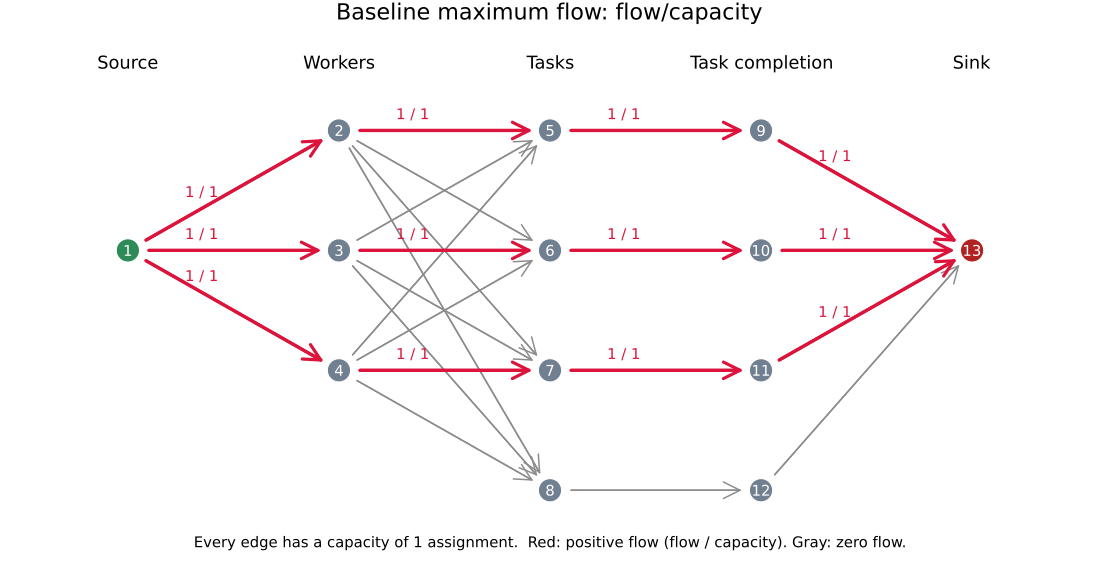

In [5]:
# Position the nodes for the drawing; row v stores node v's (x, y) coordinates -
node_coordinates = [
    10.0 10.0; # source: node 1
    11.0 11.0; # workers: nodes 2–4
    11.0 10.0;
    11.0  9.0;
    12.0 11.0; # tasks: nodes 5–8
    12.0 10.0;
    12.0  9.0;
    12.0  8.0;
    13.0 11.0; # task completion: nodes 9–12
    13.0 10.0;
    13.0  9.0;
    13.0  8.0;
    14.0 10.0; # sink: node 13
];

# Highlight the edges carrying the baseline flow -
plot_flow_network(baseline_graph, node_coordinates;
    flow = baseline_flow, theme = :auto,
    title = "Baseline maximum flow: flow/capacity")


Worker `2` completes task `5`, worker `3` completes task `6`, and worker `4` completes task `7`. Each assignment follows one route through a completion node to the sink, and task `8` receives no flow. Other maximum flows may pair the workers and tasks differently while completing the same total. To establish that the maximum is three assignments, we need an upper bound on the flow that any feasible assignment can achieve.

### Establish optimality with a cut

Consider the source–sink cut with $S=\{1\}$ containing only the source and $T=\mathcal{V}\setminus S$ containing all other nodes, where $\mathcal{V}$ is the network's vertex set. The cut capacity $c(S,T)$ is the sum of the capacities on edges directed from $S$ to $T$. The three source-to-worker edges cross this cut, each with capacity one assignment, so its capacity is given by:

$$
c(S,T)=c(1,2)+c(1,3)+c(1,4)=1+1+1=3.
$$

Every feasible flow satisfies $|f|\leq c(S,T)$, where $|f|$ is its net source outflow. A feasible flow that reaches the cut capacity is therefore maximum.

Let's draw this cut on the baseline flow. Red edges cross from $S$ to $T$ and are labeled `flow/capacity`; dark gray edges carry flow inside $T$; light gray edges carry no flow:

<style>
  .course-diagram { color-scheme: light dark; }
  :host-context(body[data-vscode-theme-kind="vscode-light"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast-light"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-light"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast-light"] .course-diagram { color-scheme: light; }
  :host-context(body[data-vscode-theme-kind="vscode-dark"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-dark"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast"] .course-diagram { color-scheme: dark; }
  @media print { .course-diagram { color-scheme: only light !important; } }
</style>
<p align="center">
<img class="course-diagram" src="figs/Fig-Baseline-SourceCut/Fig-Baseline-SourceCut.svg" width="800" style="display:block; margin:0 auto;" alt="The 13-node worker–task network with S containing only the source and T containing every other node. The three source-to-worker edges cross the cut in red, each labeled 1/1. Inside T, the flow continues from workers 2, 3, and 4 to tasks 5, 6, and 7, through completion nodes 9, 10, and 11, to the sink. Task 8 carries no flow.">
</p>

The three red edges leave $S$, and each carries its full capacity, so the flow across the cut is $1+1+1=3$ and equals $c(S,T)$. No edge returns from $T$ to $S$, and the gray edges inside $T$ only carry those three units onward to the sink. Let's compute this bound from `baseline_graph.capacity` and check that the independently validated flow reaches it:


In [6]:
# Compute the capacity of the cut containing only the source -
# edge = (source, target); bounds = (lower, upper), in assignments.
# The generator feeds only capacities crossing the cut into the sum.
# Julia syntax: https://docs.julialang.org/en/v1/manual/arrays/#Generator-Expressions
baseline_cut_capacity = sum((
    bounds[2] for (edge, bounds) in baseline_graph.capacity
    if edge[1] == source_id && edge[2] != source_id
); init = 0.0); # upper bound on completed assignments

# Feasibility and equality with the cut bound together establish maximum flow -
@testset "Baseline feasibility and optimality" begin
    @test baseline_report.valid
    @test baseline_value_ok
    @test isapprox(baseline_report.value, baseline_cut_capacity; atol = flow_atol, rtol = 0)
end;

println("Validated baseline flow: ", baseline_report.value, " assignments")
println("Source-cut capacity: ", baseline_cut_capacity, " assignments")


Test Summary:                       | Pass  

Total  Time
Baseline feasibility and optimality |    3      3  0.3s
Validated baseline flow: 3.0 assignments
Source-cut capacity: 3.0 assignments


The validated flow reaches the cut capacity of three assignments, establishing the baseline maximum. Four tasks are available, but the three workers can accept only one assignment each. One task must remain unassigned.

These numerical results apply to the supplied network; changing the edge list or capacities may change the flow value and the cut needed to establish optimality. We will compare each intervention with this same baseline.


___

## Task 2: Give worker 3 capacity for a second assignment

In this task, we increase the capacity of the edge from the source to worker node `3` from one to two assignments and determine whether the network can complete more work. The other two workers can still accept one assignment each, and every task still requires one worker.

### Predict the effect of the capacity change

Before running the next cell, predict the maximum number of completed assignments. How does the capacity of the source-only cut change? Can worker `3` send two units to distinct tasks while the other two workers each complete one task? Use the network's connections and capacities to explain your prediction.

We first make an independent copy of `baseline_graph` and store it in `expanded_graph`. This preserves the original network for comparison. We then change only the upper capacity on edge `(1, 3)` and recompute the maximum flow. The tuple `(0.0, expanded_worker_capacity)` retains the zero lower bound and sets the worker's new assignment capacity:


In [7]:
# Increase one worker's capacity in a copy of the baseline network -
worker_id = 3; # worker node used in the capacity and outage scenarios
expanded_worker_capacity = 2.0; # maximum assignments this worker can accept [assignments]
expanded_graph = deepcopy(baseline_graph); # copy the capacity dictionary as well as the graph

# Bounds are (lower, upper), in assignments.
expanded_graph.capacity[(source_id, worker_id)] = (0.0, expanded_worker_capacity); # reset the upper bound for this worker's edge from the source

# Recompute the maximum flow -
expanded_value, expanded_flow = maximumflow(
    expanded_graph, expanded_graph.nodes[source_id], expanded_graph.nodes[sink_id];
    algorithm = EdmondsKarpAlgorithm(), atol = flow_atol,
);

### Verify the new flow and explain the gain

We apply the same checks as in Task 1 using [the `validate_sensitivity_flow(...)` function](docs/validate_sensitivity_flow.md), then compare the independently calculated flow value with `expanded_value`. The cut with $S=\{1\}$ and all other nodes in $T$ now has capacity:

$$
c(S,T)=c(1,2)+c(1,3)+c(1,4)=1+2+1=4.
$$

Here, $c(u,v)$ is the upper capacity of edge $(u,v)$, measured in assignments. A feasible flow of four reaches this upper bound and is therefore maximum. Let's draw the same cut on the expanded flow. Red edges cross from $S$ to $T$ and are labeled `flow/capacity`; dark gray edges carry flow inside $T$; light gray edges carry no flow:

<style>
  .course-diagram { color-scheme: light dark; }
  :host-context(body[data-vscode-theme-kind="vscode-light"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast-light"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-light"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast-light"] .course-diagram { color-scheme: light; }
  :host-context(body[data-vscode-theme-kind="vscode-dark"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-dark"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast"] .course-diagram { color-scheme: dark; }
  @media print { .course-diagram { color-scheme: only light !important; } }
</style>
<p align="center">
<img class="course-diagram" src="figs/Fig-Expanded-SourceCut/Fig-Expanded-SourceCut.svg" width="800" style="display:block; margin:0 auto;" alt="The same network after the edge from the source to worker 3 gains capacity two. The three red edges crossing the cut are labeled 1/1, 2/2, and 1/1. Inside T, worker 3 sends one unit each to tasks 6 and 7, worker 2 to task 5, and worker 4 to task 8, so all four completion edges and all four sink edges carry flow.">
</p>

The same cut now includes edge $(1,3)$ with capacity two instead of one. All three red edges are still full, so the flow across the cut is $1+2+1=4$ and again equals $c(S,T)$. Inside $T$, worker `3` carries its two units to different tasks, and every task-to-completion edge is full. Let's compute the cut capacity from the modified graph and check this equality. We also verify that the original source-to-worker capacity remains one assignment in `baseline_graph`:

In [8]:
# Independently check the expanded flow and reported total -
expanded_report = validate_sensitivity_flow(
    expanded_graph, expanded_flow, source_id, sink_id; atol = flow_atol,
);
expanded_value_ok = isapprox(expanded_report.value, expanded_value; atol = flow_atol, rtol = 0);

# Compute the source-only cut capacity in the modified graph -
# Sum upper capacities on edges from the source to other nodes.
expanded_cut_capacity = sum((
    bounds[2] for (edge, bounds) in expanded_graph.capacity
    if edge[1] == source_id && edge[2] != source_id
); init = 0.0); # upper bound on completed assignments after expansion

# Require feasibility, agreement with the cut bound, and an unchanged baseline -
@test expanded_report.valid;
@test expanded_value_ok;
@test isapprox(expanded_report.value, expanded_cut_capacity; atol = flow_atol, rtol = 0);
@test baseline_graph.capacity[(source_id, worker_id)] == (0.0, 1.0);

The checks pass for the supplied network. Let's compare the validated maximum flow, source-cut capacity, and gain relative to the baseline in one table. All numerical entries are measured in assignments:


In [9]:
# Compare the baseline and expanded networks -
expansion_results = DataFrame(
    "Scenario" => ["Baseline", "Expanded"],
    "Maximum flow" => [baseline_report.value, expanded_report.value],
    "Cut capacity" => [baseline_cut_capacity, expanded_cut_capacity],
    "Gain" => [0.0, expanded_report.value - baseline_report.value],
);
pretty_table(expansion_results)


┌──────────┬──────────────┬──────────────┬─────────┐
│ Scenario │ Maximum flow │ Cut capacity │    Gain │
│   String │      Float64 │      Float64 │ Float64 │
├──────────┼──────────────┼──────────────┼─────────┤
│ Baseline │          3.0 │          3.0 │     0.0 │
│ Expanded │          4.0 │          4.0 │     1.0 │
└──────────┴──────────────┴──────────────┴─────────┘


Let's draw the expanded flow with the same node positions. The edge from the source to worker `3` now has capacity two and is labeled; every other edge keeps capacity one:


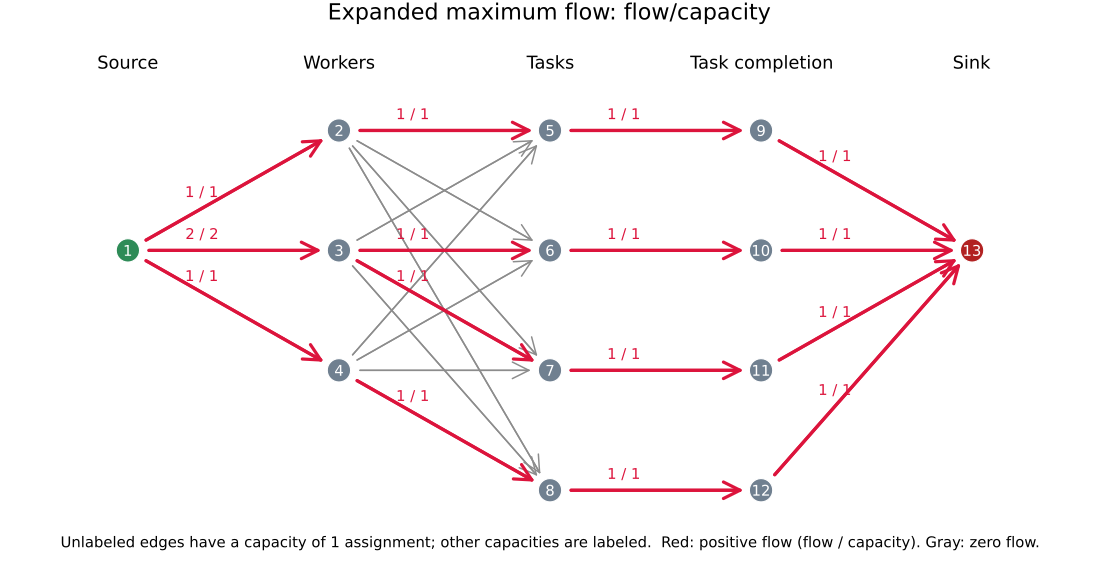

In [10]:
# Highlight the edges carrying the expanded flow -
plot_flow_network(expanded_graph, node_coordinates;
    flow = expanded_flow, theme = :auto,
    title = "Expanded maximum flow: flow/capacity")


The validated flow and cut capacity both equal four assignments, one more than the baseline: worker `3` now completes tasks `6` and `7`, and worker `4` moves from task `7` to task `8`, so every task is assigned. Next, we return to a separate copy of the baseline and examine what happens when worker `3` becomes unavailable.

___

## Task 3: Examine a worker outage and compare the interventions

In this task, we make worker `3` unavailable by setting the capacities of its outgoing edges to zero. We block the outgoing edges rather than the edge from the source so that the cut containing only the source keeps its capacity of three; this choice tests whether the cut from Tasks 1 and 2 still explains the result. We then compute the maximum flow and compare the outage with the baseline and capacity-expansion scenarios. The outage starts from a separate copy of the baseline, where each worker can accept one assignment.

### Predict the effect of the outage

The four edges from worker `3` to the task nodes will have zero capacity, while the edge from the source to worker `3` will retain its capacity of one assignment. Can conservation allow positive flow into worker `3` when no flow can leave it? 

We store an independent copy of the baseline in `outage_graph`. The loop identifies every edge leaving `worker_id` and sets its lower and upper flow bounds to zero. We then recompute the maximum flow:

In [11]:
# Block the worker's outgoing edges in a copy of the baseline network -
outage_graph = deepcopy(baseline_graph); # use the baseline for this separate intervention
for edge in keys(outage_graph.capacity)
    if edge[1] == worker_id # the first endpoint identifies the edge's source
        outage_graph.capacity[edge] = (0.0, 0.0); # unavailable worker cannot accept tasks
    end
end

# Recompute the maximum flow -
outage_value, outage_flow = maximumflow(
    outage_graph, outage_graph.nodes[source_id], outage_graph.nodes[sink_id];
    algorithm = EdmondsKarpAlgorithm(), atol = flow_atol,
);

Let's draw the outage flow with the same node positions. The four blocked edges leaving worker `3` are labeled `0 / 0`; every other edge keeps capacity one:


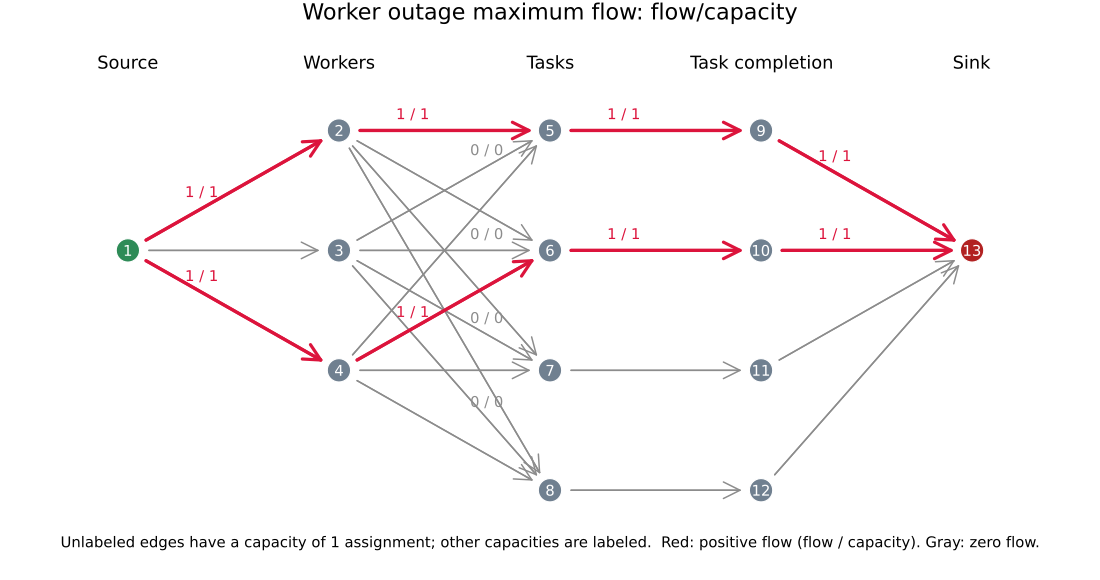

In [12]:
# Highlight the edges carrying the outage flow -
plot_flow_network(outage_graph, node_coordinates;
    flow = outage_flow, theme = :auto,
    title = "Worker outage maximum flow: flow/capacity")


Workers `2` and `4` complete tasks `5` and `6`, and tasks `7` and `8` receive no flow. The edge from the source to worker `3` is gray: it still has capacity one, but conservation at worker `3` leaves it empty because nothing can leave that node.


### Verify the flow using a different cut

The source-to-worker capacities have not changed, so the cut containing only the source still has capacity three. However, worker `3` cannot send flow to any task. Conservation therefore forces its incoming flow to zero, leaving only workers `2` and `4` able to complete assignments.

To obtain a bound that accounts for the outage, choose $S=\{1,3\}$ and $T=\mathcal{V}\setminus S$, where $\mathcal{V}$ is the network's vertex set. Edge $(1,3)$ lies entirely inside $S$ and does not cross the cut. The crossing edges are $(1,2)$, $(1,4)$, and the four zero-capacity edges from worker `3` to the tasks. Their total capacity is given by:

$$
c(S,T)=c(1,2)+c(1,4)+\sum_{v=5}^{8}c(3,v)=1+1+0=2.
$$

Here, $c(u,v)$ is the upper capacity of edge $(u,v)$, measured in assignments. A feasible flow of two reaches this bound and is therefore maximum. Let's draw this cut on the outage flow. The box for $S$ now reaches into the worker column to enclose worker `3`:

<style>
  .course-diagram { color-scheme: light dark; }
  :host-context(body[data-vscode-theme-kind="vscode-light"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast-light"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-light"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast-light"] .course-diagram { color-scheme: light; }
  :host-context(body[data-vscode-theme-kind="vscode-dark"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-dark"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast"] .course-diagram { color-scheme: dark; }
  @media print { .course-diagram { color-scheme: only light !important; } }
</style>
<p align="center">
<img class="course-diagram" src="figs/Fig-Outage-WorkerCut/Fig-Outage-WorkerCut.svg" width="800" style="display:block; margin:0 auto;" alt="The 13-node worker–task network with S containing the source and worker 3, drawn as a box reaching into the worker column, and T containing every other node. The edges from the source to workers 2 and 4 cross the cut in red, labeled 1/1. Worker 3's four dashed red edges to the tasks are labeled 0/0. The edge from the source to worker 3 lies inside S and is labeled 0/1. Inside T, worker 2 completes task 5 and worker 4 completes task 6, and those two units reach the sink.">
</p>

Two red edges leave $S$ with capacity one each, and the four dashed red edges leave $S$ with capacity zero, so $c(S,T)=2$. The edge $(1,3)$ stays inside $S$; its unused capacity of one is what made the source-only cut too loose. The flow across the cut is $1+1=2$ and equals $c(S,T)$. We use [the `validate_sensitivity_flow(...)` function](docs/validate_sensitivity_flow.md) to check feasibility, compare its independently calculated value with `outage_value`, and check that the flow reaches the cut capacity:


In [13]:
# Independently check the outage flow and reported total -
outage_report = validate_sensitivity_flow(
    outage_graph, outage_flow, source_id, sink_id; atol = flow_atol,
);
outage_value_ok = isapprox(outage_report.value, outage_value; atol = flow_atol, rtol = 0);

# Sum capacities on edges crossing from S to its complement T -
outage_cut_source_nodes = Set([source_id, worker_id]); # S contains the source and unavailable worker
# Include only edges with their source in S and their target outside S.
outage_cut_capacity = sum((
    bounds[2] for (edge, bounds) in outage_graph.capacity
    if edge[1] in outage_cut_source_nodes && !(edge[2] in outage_cut_source_nodes)
); init = 0.0); # upper bound on completed assignments during the outage

# Require feasibility, agreement with the cut bound, and an unchanged baseline -
@test outage_report.valid;
@test outage_value_ok;
@test isapprox(outage_report.value, outage_cut_capacity; atol = flow_atol, rtol = 0);
# Check every outgoing worker edge for accidental changes to the baseline.
@test all(
    bounds == (0.0, 1.0) for (edge, bounds) in baseline_graph.capacity
    if edge[1] == worker_id
);


### Compare the three scenarios

The checks pass for the supplied network. Let's place all three scenarios in one table, using the independently validated flow values and the cut capacities that establish their optimality. Each change is measured relative to the same baseline; a negative value indicates fewer completed assignments. All numerical entries are measured in assignments:


In [14]:
# Compare each intervention with the original baseline -
scenario_results = DataFrame(
    "Scenario" => ["Baseline", "Expanded", "Worker outage"],
    "Maximum flow" => [baseline_report.value, expanded_report.value, outage_report.value],
    "Cut capacity" => [baseline_cut_capacity, expanded_cut_capacity, outage_cut_capacity],
    "Change from baseline" => [0.0, expanded_report.value - baseline_report.value,
        outage_report.value - baseline_report.value],
);
pretty_table(scenario_results)

┌───────────────┬──────────────┬──────────────┬──────────────────────┐
│      Scenario │ Maximum flow │ Cut capacity │ Change from baseline │
│        String │      Float64 │      Float64 │              Float64 │
├───────────────┼──────────────┼──────────────┼──────────────────────┤
│      Baseline │          3.0 │          3.0 │                  0.0 │
│      Expanded │          4.0 │          4.0 │                  1.0 │
│ Worker outage │          2.0 │          2.0 │                 -1.0 │
└───────────────┴──────────────┴──────────────┴──────────────────────┘


The baseline completes three assignments. Increasing worker `3`'s capacity allows all four tasks to be completed, while making that worker unavailable reduces the maximum to two. These are separate interventions: the outage loses one assignment relative to the baseline.

In each scenario, the validated flow reaches the listed cut capacity. The outage also shows why the cut must reflect the available routes: the source still has three units of outgoing capacity, but only two can reach the sink. Increasing the capacity of edge `(1, 3)` would not restore the lost assignment while all of worker `3`'s outgoing edges remain blocked.


___

## Summary

We used a worker–task network to examine how increasing a worker's capacity or making that worker unavailable changes the maximum number of completed assignments.

> __Key Takeaways__
>
> * **Certifying the baseline:** We computed a flow of three assignments and checked it independently for capacity, conservation, and source–sink balance. Because that feasible flow reached the capacity of the cut containing only the source, the cut certified the solver's total as the maximum rather than taking it on trust.
>
> * **Propagating a capacity increase:** We gave worker `3` a second assignment slot, and the maximum rose from three to four because the remaining network could carry the extra unit to a task and on to the sink. The four task-to-completion edges then became the limit, so more capacity at that worker would not add a fifth assignment: a local increase helps only when the rest of the network can absorb it.
>
> * **Certifying an outage with a different cut:** We blocked worker `3`'s outgoing edges, and the maximum fell to two even though the cut containing only the source still had capacity three. The cut with $S=\{1,3\}$ had capacity two and certified the new maximum, showing that the binding cut moves with the routes that remain available.

In [the L5c lecture](../L5c/CHEME-5800-L5c-Lecture-LinearProgramming-Fall-2026.ipynb), we will express network-flow conservation and capacity requirements as linear constraints and introduce costs into the optimization model.

___